# Model-5: Caltech 256 Dataset, Inception Style Branches, Depthwise Separable Convolutions, SiLU Activation, Residual Connections, Layer Norm

- Residual Blocks add skip connections to improve gradient flow and feature reuse
- Depthwise Separable Convolution reduces the number of parameters while maintaining performance
- Inception blocks allow multi-scale feature extraction

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets

In [2]:
try:
    from torchinfo import summary
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "torchinfo"])
    from torchinfo import summary

In [3]:
try:
    import torchmetrics
except ImportError:
    import subprocess
    subprocess.check_call(["pip", "install", "torchmetrics"])
    import torchmetrics

In [4]:
import os
repo_url = "https://raw.githubusercontent.com/vardanskamra/Deep-Multimedia-Steganography/main/utils"
files = [
    "__init__.py",
    "test.py",
    "train.py",
    "metrics.py",
    "transforms.py",
    "visualizations.py",
    "inference.py"
]
os.makedirs("utils", exist_ok=True)

for file in files:
    file_url = f"{repo_url}/{file}"
    os.system(f"curl -s {file_url} -o utils/{file}")

print("Downloaded all utils files successfully!")

Downloaded all utils files successfully!


In [5]:
import sys
sys.path.append("./utils") 

In [6]:
import utils

from utils.transforms import caltech256_train_test_transform
from utils.metrics import loss_function
from utils.train import train
from utils.test import test

from utils.visualizations import plot_metrics
from utils.visualizations import visualize_images

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
dataset = datasets.Caltech256(root='./data', download=True, transform=caltech256_train_test_transform)

# Use 100% of the dataset
subset_size = int(1 * len(dataset))  
train_size = int(0.8 * subset_size)  
test_size = subset_size - train_size  

subset_dataset, _ = torch.utils.data.random_split(dataset, [subset_size, len(dataset) - subset_size])

train_dataset, test_dataset = torch.utils.data.random_split(subset_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=os.cpu_count(), drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=True)


Files already downloaded and verified


In [9]:
print(f"Train Dataset Length: {len(train_dataset)}")
print(f"Test Dataset Length: {len(test_dataset)}")
print(f"Train DataLoader Length: {len(train_loader)}")
print(f"Test DataLoader Length: {len(test_loader)}")

sample, label = next(iter(train_loader))
print(f"Sample Shape: {sample.shape}")
print(f"Label Shape: {label.shape}")

Train Dataset Length: 24485
Test Dataset Length: 6122
Train DataLoader Length: 765
Test DataLoader Length: 191
Sample Shape: torch.Size([32, 3, 128, 128])
Label Shape: torch.Size([32])


In [10]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding)
        self.norm = nn.LayerNorm([out_channels, 128, 128])  # LayerNorm instead of BatchNorm
        self.silu = nn.SiLU()  # Swish activation

    def forward(self, x):
        return self.silu(self.norm(self.conv(x)))

In [11]:
class ConvBranch(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes):
        super(ConvBranch, self).__init__()
        layers = []
        for k in kernel_sizes:
            layers.append(ConvBlock(in_channels, out_channels, k, padding=k//2))
            in_channels = out_channels  # Maintain consistent channels through layers
        self.branch = nn.Sequential(*layers)

    def forward(self, x):
        return self.branch(x)

In [12]:
class PrepNetwork(nn.Module):
    def __init__(self):
        super(PrepNetwork, self).__init__()
        self.branch1 = ConvBranch(3, 64, [3, 3, 3])
        self.branch2 = ConvBranch(3, 64, [5, 5, 5])
        self.branch3 = ConvBranch(3, 64, [7, 7, 7])
        self.final_conv = ConvBlock(192, 3, 3, padding=1)

    def forward(self, secret):
        b1 = self.branch1(secret)
        b2 = self.branch2(secret)
        b3 = self.branch3(secret)
        combined = torch.cat([b1, b2, b3], dim=1)
        return self.final_conv(combined)


In [13]:
class HidingNetwork(nn.Module):
    def __init__(self):
        super(HidingNetwork, self).__init__()
        self.conv1 = ConvBlock(6, 128, 3, padding=1)
        self.conv2 = ConvBlock(128, 128, 3, padding=1)
        self.conv3 = ConvBlock(128, 3, 3, padding=1)

    def forward(self, cover, secret_prepared):
        x = torch.cat([cover, secret_prepared], dim=1)
        x = self.conv1(x)
        x = self.conv2(x)
        return self.conv3(x)

In [14]:
class RevealNetwork(nn.Module):
    def __init__(self):
        super(RevealNetwork, self).__init__()
        self.conv1 = ConvBlock(3, 128, 3, padding=1)
        self.conv2 = ConvBlock(128, 128, 3, padding=1)
        self.conv3 = ConvBlock(128, 3, 3, padding=1)

    def forward(self, stego):
        x = self.conv1(stego)
        x = self.conv2(x)
        return self.conv3(x)


In [15]:
print(f"Device: {device}")
prep_net = nn.DataParallel(PrepNetwork()).to(device)
hide_net = nn.DataParallel(HidingNetwork()).to(device)
reveal_net = nn.DataParallel(RevealNetwork()).to(device)

Device: cuda


In [16]:
print("PrepNetwork Summary:")
print(summary(prep_net, input_size=(32, 3, 128, 128)))

cover = torch.randn(32, 3, 128, 128)
secret_prepared = torch.randn(32, 3, 128, 128)

print("\nHidingNetwork Summary:")
print(summary(hide_net, input_data=[cover, secret_prepared])) # 6 channels (cover + secret_prepared)

print("\nRevealNetwork Summary:")
print(summary(reveal_net, input_size=(32, 3, 128, 128)))

PrepNetwork Summary:
Layer (type:depth-idx)                        Output Shape              Param #
DataParallel                                  [32, 3, 128, 128]         --
├─PrepNetwork: 1-1                            [16, 3, 128, 128]         19,674,307
├─PrepNetwork: 1-4                            --                        (recursive)
│    └─ConvBranch: 2-1                        [16, 64, 128, 128]        6,367,104
│    └─ConvBranch: 2-4                        --                        (recursive)
│    │    └─Sequential: 3-1                   [16, 64, 128, 128]        6,367,104
│    │    └─Sequential: 3-4                   --                        (recursive)
├─PrepNetwork: 1-3                            [16, 3, 128, 128]         --
├─PrepNetwork: 1-4                            --                        (recursive)
│    └─ConvBranch: 2-3                        [16, 64, 128, 128]        --
│    └─ConvBranch: 2-4                        --                        (recursive)
│    │ 

In [17]:
optimizer = torch.optim.Adam(list(prep_net.parameters()) +
                       list(hide_net.parameters()) +
                       list(reveal_net.parameters()), lr=0.001)

In [18]:
train_metrics = train(dataloader=train_loader,
                prep_net=prep_net,
                hide_net=hide_net,
                reveal_net=reveal_net,
                optimizer=optimizer,
                loss_fn=loss_function,
                beta=0.75,
                epochs=50,
                device=device)

/usr/local/lib/python3.10/dist-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `PeakSignalNoiseRatio` from `torchmetrics` was deprecated and will be removed in 2.0. Import `PeakSignalNoiseRatio` from `torchmetrics.image` instead.
  _future_warning(
/usr/local/lib/python3.10/dist-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


Epoch [1/50], Loss: 0.4003, PSNR: 12.6663, SSIM: 0.2417, NC: 0.6547, Pixel Loss (Cover-Stego): 0.3876, Pixel Loss (Secret-Revealed): 0.4029
Epoch [2/50], Loss: 0.3103, PSNR: 13.5952, SSIM: 0.3301, NC: 0.7814, Pixel Loss (Cover-Stego): 0.3431, Pixel Loss (Secret-Revealed): 0.3391
Epoch [3/50], Loss: 0.2746, PSNR: 13.9623, SSIM: 0.3691, NC: 0.8263, Pixel Loss (Cover-Stego): 0.3229, Pixel Loss (Secret-Revealed): 0.3018
Epoch [4/50], Loss: 0.2453, PSNR: 14.3255, SSIM: 0.4017, NC: 0.8590, Pixel Loss (Cover-Stego): 0.3033, Pixel Loss (Secret-Revealed): 0.2718
Epoch [5/50], Loss: 0.2244, PSNR: 14.7267, SSIM: 0.4341, NC: 0.8745, Pixel Loss (Cover-Stego): 0.2839, Pixel Loss (Secret-Revealed): 0.2563
Epoch [6/50], Loss: 0.2101, PSNR: 15.0059, SSIM: 0.4597, NC: 0.8846, Pixel Loss (Cover-Stego): 0.2698, Pixel Loss (Secret-Revealed): 0.2447
Epoch [7/50], Loss: 0.2006, PSNR: 15.2445, SSIM: 0.4791, NC: 0.8912, Pixel Loss (Cover-Stego): 0.2594, Pixel Loss (Secret-Revealed): 0.2389
Epoch [8/50], Loss: 

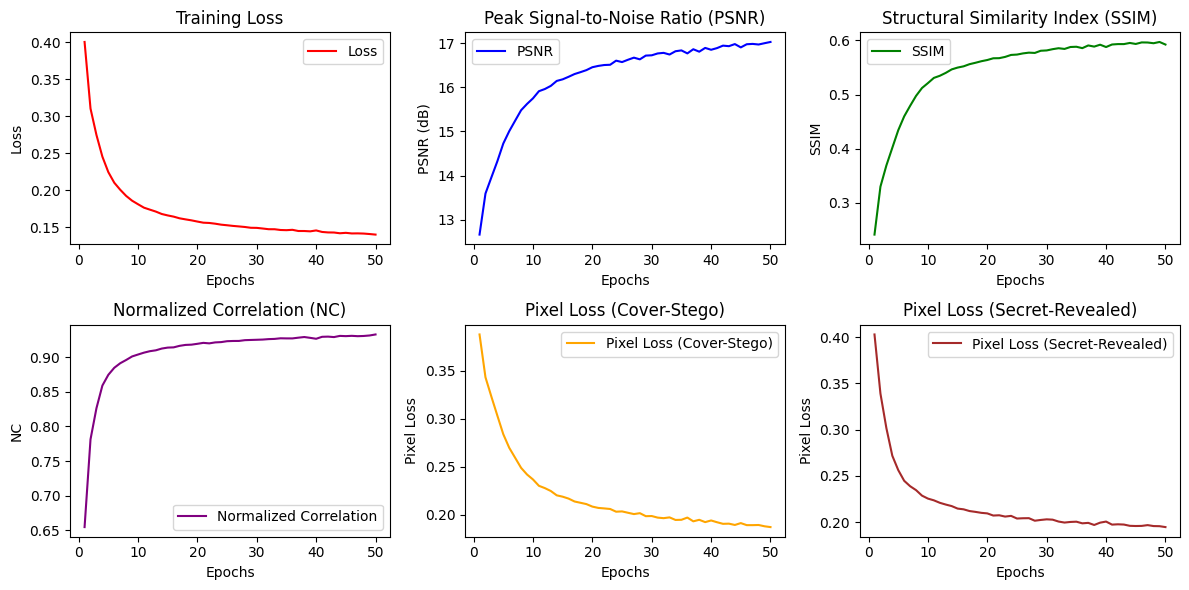


Final Evaluation Metrics:
Final Loss: 0.1399
Final PSNR: 17.0254 dB
Final SSIM: 0.5922
Final Normalized Correlation (NC): 0.9327
Final Pixel Loss (Cover-Stego): 0.1874
Final Pixel Loss (Secret-Revealed): 0.1947



In [19]:
plot_metrics(train_metrics)

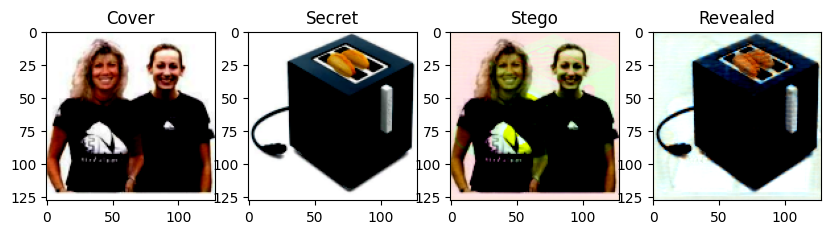

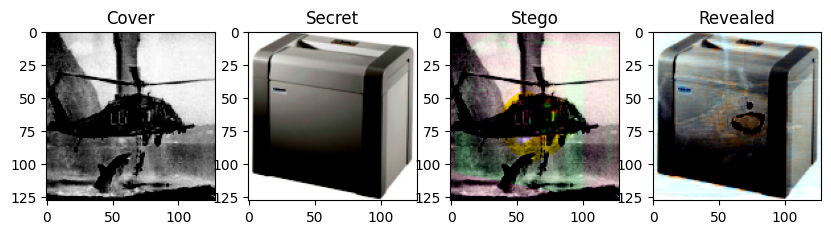

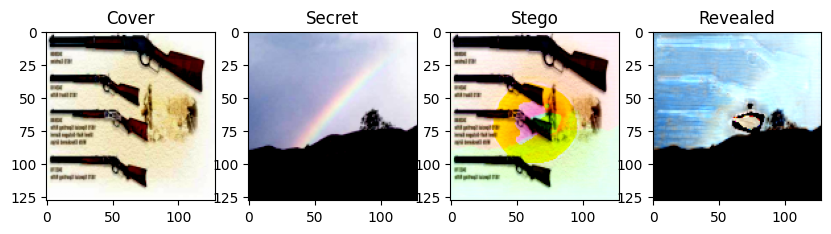

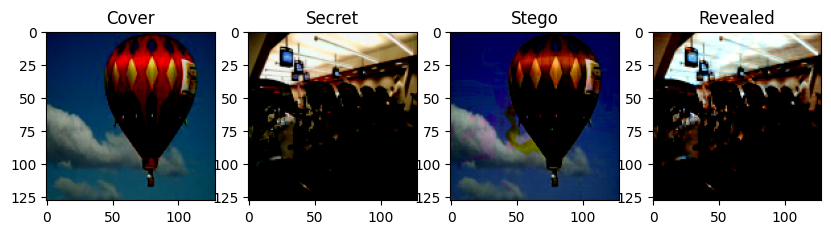

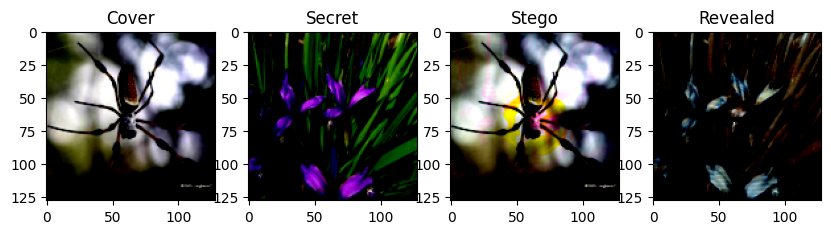

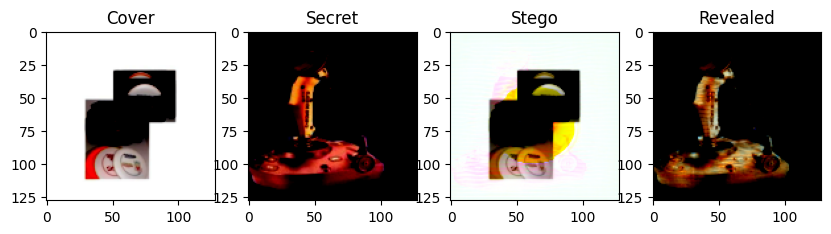

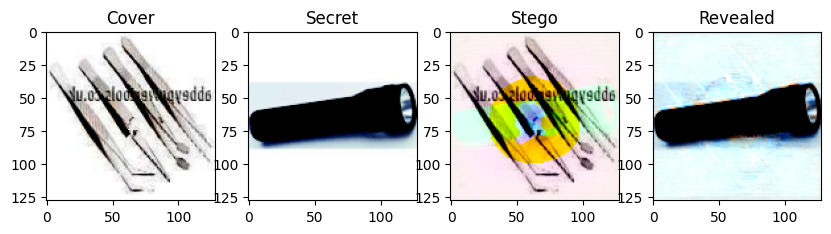

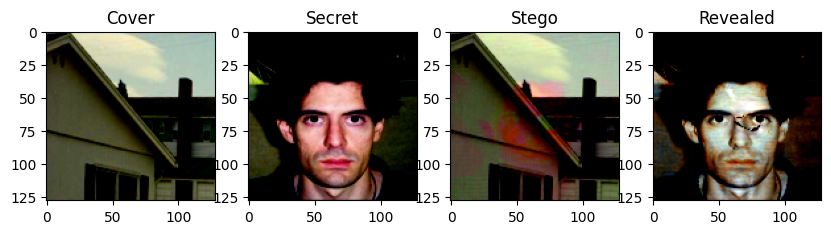

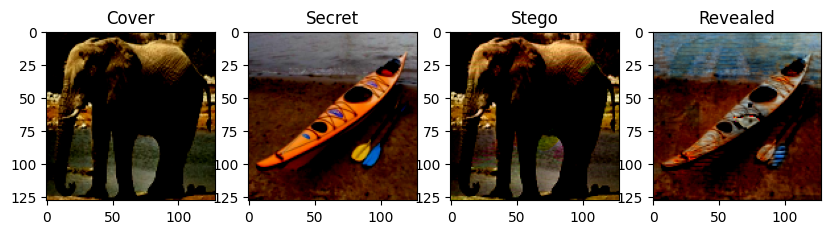


Test Results: Loss: 0.1385, PSNR: 17.0961, SSIM: 0.5796, NC: 0.9350, Pixel Loss (Cover-Stego): 0.1861, Pixel Loss (Secret-Revealed): 0.1943



In [20]:
test_metrics = test(prep_net=prep_net,
               hide_net=hide_net,
               reveal_net=reveal_net,
               dataloader=test_loader,
               loss_fn = loss_function,
               beta = 0.75,
               visualize = True,
               device=device)

In [22]:
torch.save(prep_net.state_dict(), "/kaggle/working/prep_net.pth")
torch.save(hide_net.state_dict(), "/kaggle/working/hide_net.pth")
torch.save(reveal_net.state_dict(), "/kaggle/working/reveal_net.pth")